In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install flowio

In [3]:
import pandas as pd
import pickle
import os
import numpy as np
import sys

In [4]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'


if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/Old_CellCNN/old_cellCnn/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/Ubuntu/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}/New running ipynb/Final_notebooks/modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [5]:
decache_files = ['timepoints_elaboration', 'functions', 'show_results']


# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)

from timepoints_elaboration import load_data, donation_extraction

from show_results import retireve_samples_info, show_patients_samples_info, elaborate_direct_prediction
from show_results import retrieve_blast_perc, comulative_num_samples_sum, elaborate_ens_data_for_box_violin
from show_results import show_dotbox_heat, show_ensamble_heatmap, show_dotbox_dotbox, show_all_LOPO_boxplots
from show_results import retrieve_all_LOPO_thresholds, elaborate_data_for_box_violin, retrieve_all_LOPO_ensamble_thresholds

from functions import generate_LOPOCV_dicts, generate_LOPOCV_folds, flatten, compute_metrics, compute_mean_std_metrics, robust_prediction_labelling
from functions import show_blast_distribution_perc, seed_level_robust_prediction_labelling, retireve_sorted_pat_sample_ids, retrieve_labels



timepoints_elaboration rimosso dalla cache
functions non trovato nella cache
show_results non trovato nella cache


In [6]:

data_folder_dir = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder_dir, ext = extension)#, remove_control = True)


0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

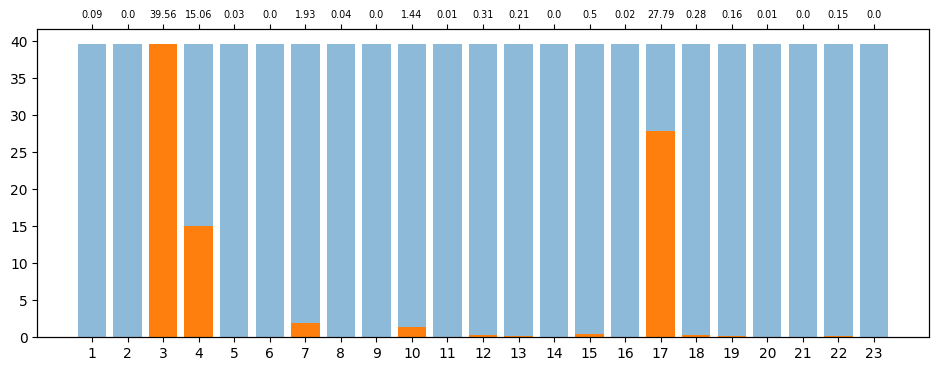

[np.float64(0.09), np.float64(0.0), np.float64(39.56), np.float64(15.06), np.float64(0.03), np.float64(0.0), np.float64(1.93), np.float64(0.04), np.float64(0.0), np.float64(1.44), np.float64(0.01), np.float64(0.31), np.float64(0.21), np.float64(0.0), np.float64(0.5), np.float64(0.02), np.float64(27.79), np.float64(0.28), np.float64(0.16), np.float64(0.01), np.float64(0.0), np.float64(0.15), np.float64(0.0)]


In [7]:

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS,multiple_donations, return_perc = True)
print(tot_perc_list)

/content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//New running ipynb/Final_notebooks/modules/show_results.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


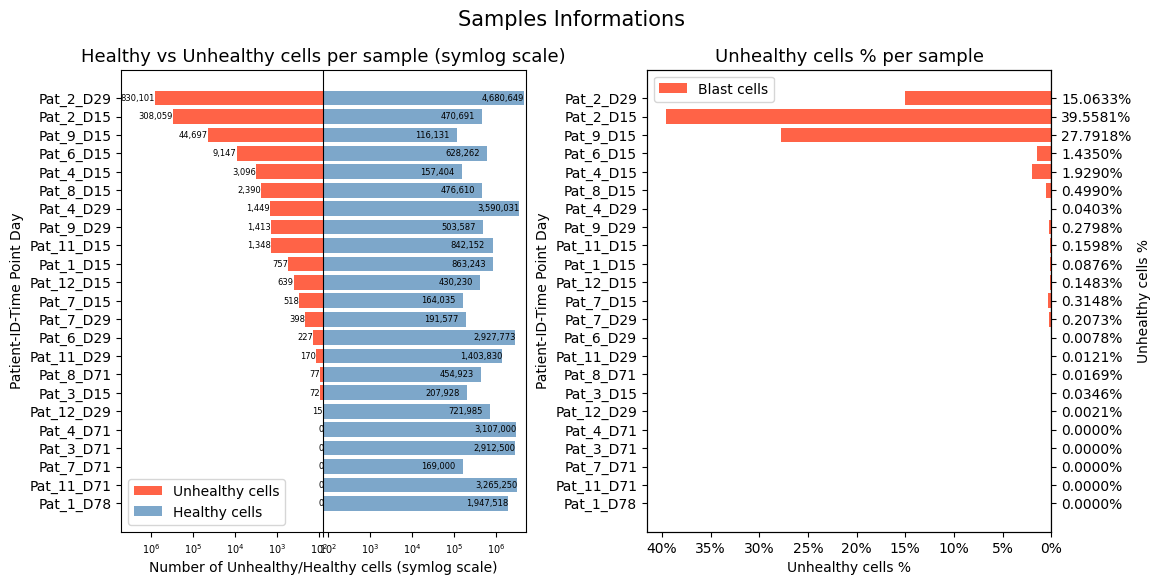

In [8]:

samples_info_dict = retireve_samples_info(data_folder_dir, multiple_donations, ALL_DATASETS)
show_patients_samples_info(samples_info_dict, numbers = True)

In [9]:

tuning_exp = 'Trial_4_NO_AS_bayesian_tuning'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)
starting_seed = config['starting_seed']

plot_exp = '5_plots'
thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)


In [10]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

# Training Procedure 2

In [11]:
exp = 'Trial_4_NO_AS_Ensemble'

#exp = 'Trial_4_AS_Ensemble'

if 'NO_AS' in exp:
    exp_plot_name = 'NO_AS'
else:
    exp_plot_name = 'AS'

sub_figsize = (4,5)

In [12]:
save_lopo_ens_dir = f'{cellcnn_path}/experiments/experiment_{exp}/'
LOPO_folds = len([fold_name for fold_name in list(os.listdir(save_lopo_ens_dir)) if 'fold' in fold_name])
print(LOPO_folds)


left_out_pat_list = []
for LOPO_idx, _ in enumerate(range(LOPO_folds)):
    save_ensemble_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPO_idx}/ensemble/results/'

    test_pat = LOPOCV_patients_folds[LOPO_idx][1]
    left_out_pat_list.append(test_pat)
left_out_pat_list = flatten(left_out_pat_list)
print(left_out_pat_list)


10
['1', '2', '3', '4', '6', '7', '8', '9', '11', '12']


In [13]:

all_dir_metrics = []
all_dir_ens_metrics = []
all_dir_metrics_across_LOPO = []
prov_all_dir_metrics_across_LOPO = []

for LOPO_idx, _ in enumerate(range(LOPO_folds)):

    save_ensemble_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPO_idx}/ensemble/results/' #inner_fold_{inner_fold}/robust/{thr_type}'
    ens_folds = len([fold_name for fold_name in list(os.listdir(save_ensemble_dir)) if 'fold' in fold_name])

    orig_pred = []

    across_folds_metrics = []
    for i, _ in enumerate(range(ens_folds)):

        # === Import LOPOCV iteration-specific CV fold results === #
        save_original_dir = f'{save_ensemble_dir}/inner_fold_{i}/predictions/direct'

        elemento_to_load = ['original_predictions_list', 'original_results_list', 'original_test_y'  ]
        loaded_elements = {}
        for element in elemento_to_load:
            with open(os.path.join(save_original_dir, f'{element}.pkl'), 'rb') as f:
                        loaded_elem = pickle.load(f)
            loaded_elements[element] = loaded_elem

        original_predictions_list = loaded_elements['original_predictions_list']
        original_results_list = loaded_elements['original_results_list']
        original_test_y = loaded_elements['original_test_y']

        # extract samples probability of belonging in the unhealthy class
        pos_pred = [sample[1] for pat in original_predictions_list for sample in pat]
        orig_pred.append(pos_pred)

        # compute metrics per inner CV fold
        fold_metrics = compute_metrics(original_test_y, pos_pred, 0.5)
        across_folds_metrics.append(fold_metrics)

        all_dir_metrics_across_LOPO.append(fold_metrics)


    # compute Ensemble metrics metrics per LOPOCV fold

    orig_pred_df = pd.DataFrame(orig_pred)
    mean_preds_across_folds = orig_pred_df.mean(axis = 0).to_numpy()

    ens_metrics = compute_metrics(original_test_y, mean_preds_across_folds, 0.5)
    all_dir_ens_metrics.append(ens_metrics)


    # store metrics in the needed format
    met_df = pd.DataFrame(across_folds_metrics)

    direct_metrics_across_folds = {}
    for met in met_df.columns:
        direct_metrics_across_folds[met] = met_df[met].to_list()

    all_dir_metrics.append(direct_metrics_across_folds)



[1 1]
[1 1]
[1 1]
[1 0]
[1 0]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 0]
[1 1]
[1 1]
[1 0]
[1 1]
[1 1 1]
[1 1 0]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1]
[1 0]
[1 0]
[1 0]
[1 1]
[1 0]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 0 0]
[1 1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]


In [14]:

save_direct_plot_dir = f'{thesis_images_dir}/{exp_plot_name}_ens/dir/'
os.makedirs(save_direct_plot_dir, exist_ok=True)
print(save_direct_plot_dir)

/content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//experiments/experiment_5_plots/thesis_images/NO_AS_ens/dir/


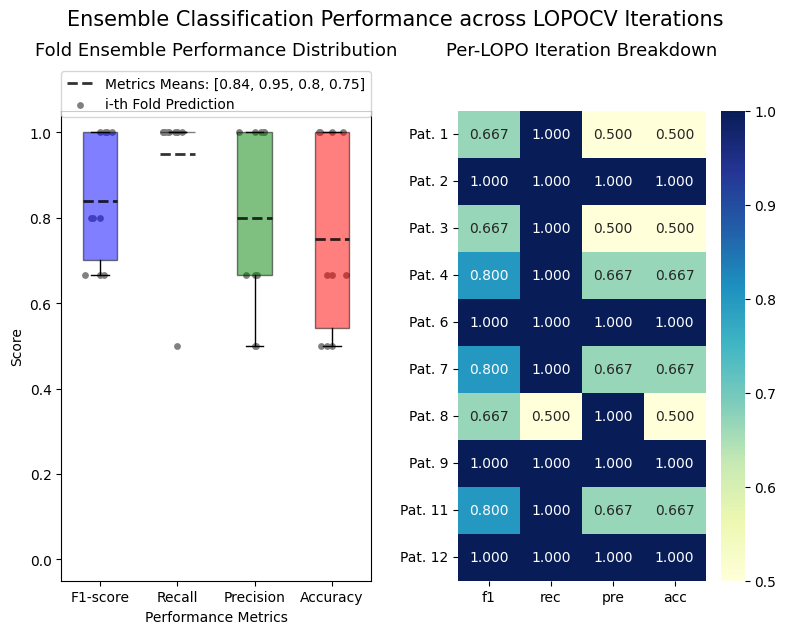

In [15]:

show_dotbox_heat(all_dir_ens_metrics,
                 dots = True,fold_or_seed = 'Fold',
                 title_1 = 'Fold Ensemble Performance Distribution',
                 title_2 = 'Per-LOPO Iteration Breakdown',
                 sup_title = 'Ensemble Classification Performance across LOPOCV Iterations',
                 file_name = f'ensemble_perf_distr_{exp_plot_name}_dir',
                 #save_dir = save_direct_plot_dir,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = sub_figsize,
                 legend_pos = 1.1)

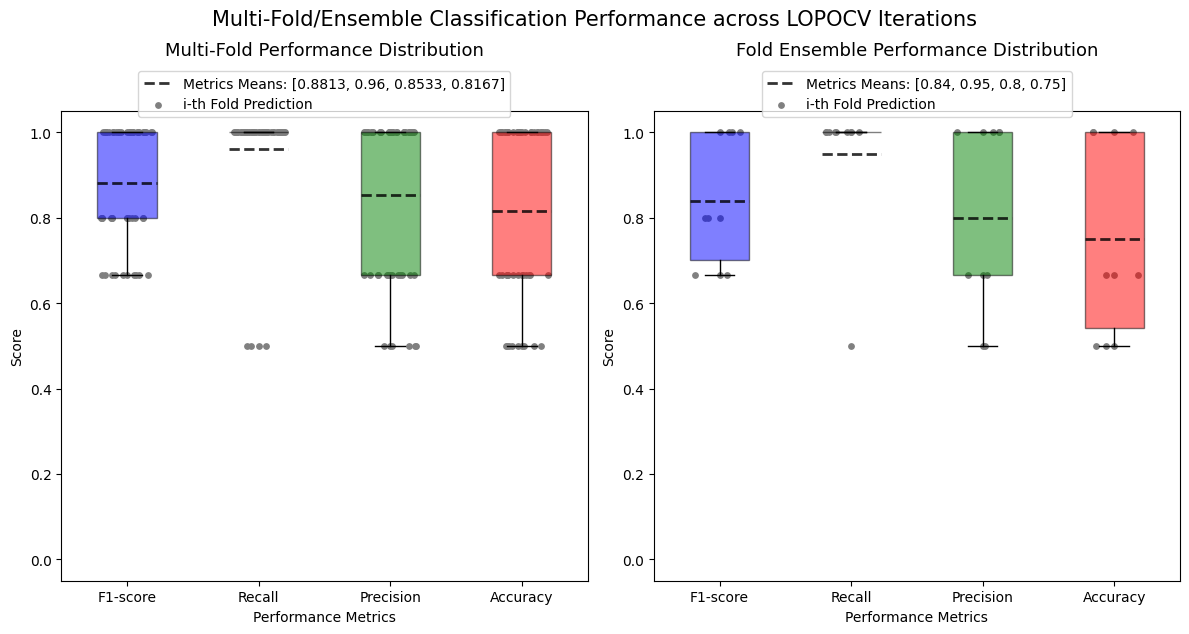

In [16]:
show_dotbox_dotbox(all_dir_ens_metrics, all_dir_metrics_across_LOPO,
                 dots = True,
                 title_1 = 'Multi-Fold Performance Distribution',
                 title_2 = 'Fold Ensemble Performance Distribution',
                 fold_or_seed = 'Fold',
                 sup_title = 'Multi-Fold/Ensemble Classification Performance across LOPOCV Iterations',
                 file_name = f'multi_ensemble_perf_distr_{exp_plot_name}_dir',
                 #save_dir = save_direct_plot_dir,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = (6,5),
                 legend_pos = 1.1)

# Ensemble Resampling Prediction (ROC)

In [17]:
# === Retrieve ROC and RES tuned thresholds === #
ens_roc_thr_per_fold, ens_res_thr_per_fold = retrieve_all_LOPO_ensamble_thresholds(LOPO_folds, cellcnn_path, exp)
print(ens_roc_thr_per_fold)
print(ens_res_thr_per_fold)

# === Elaborate Resampling Approaches === #

ens_all_roc_metrics = []
ens_all_res_metrics = []
roc_ens_metrics_dicts = []
res_ens_metrics_dicts = []
all_ROC_metrics_across_LOPO = []
all_RES_metrics_across_LOPO = []
for LOPO_idx, _ in enumerate(range(LOPO_folds)):
    ens_folds = len([fold_name for fold_name in list(os.listdir(save_ensemble_dir)) if 'fold' in fold_name])

    save_ensemble_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPO_idx}/ensemble/results/' #inner_fold_{inner_fold}/robust/{thr_type}'

    lopo_roc_thr = ens_roc_thr_per_fold[LOPO_idx]
    lopo_res_thr = ens_res_thr_per_fold[LOPO_idx]

    fold_pred = []
    for i, _ in enumerate(range(ens_folds)):

        save_robust_dir = f'{save_ensemble_dir}/inner_fold_{i}/predictions/robust/'

        with open(os.path.join(save_robust_dir, 'test_total_trial_pred_lists.pkl'), 'rb') as f:
                                    test_total_trial_pred_lists = pickle.load(f)

        with open(os.path.join(save_robust_dir, 'per_donor_original_test_y.pkl'), 'rb') as f:
                                    per_donor_original_test_y = pickle.load(f)

        true_y = flatten(per_donor_original_test_y)

        # classify samples
        _, ens_test_total_preds = robust_prediction_labelling(test_total_trial_pred_lists, lopo_roc_thr*100, pred = True)
        ens_labels_pred_flat = flatten(ens_test_total_preds)
        fold_pred.append(ens_labels_pred_flat)


        # Fold-Level classified with ROC
        roc_metrics_across_LOPO = compute_metrics(true_y, ens_labels_pred_flat, lopo_roc_thr)
        all_ROC_metrics_across_LOPO.append(roc_metrics_across_LOPO)

        # Fold-Level classified with RES
        res_metrics_across_LOPO = compute_metrics(true_y, ens_labels_pred_flat, lopo_res_thr)
        all_RES_metrics_across_LOPO.append(res_metrics_across_LOPO)

    # take the mean across inner folds prediction probabilities
    ens_pred_df = pd.DataFrame(fold_pred)
    mean_preds_across_folds = ens_pred_df.mean(axis = 0).to_numpy()

    # Ensemble classified with ROC
    roc_ens_metrics = compute_metrics(true_y, mean_preds_across_folds, lopo_roc_thr)
    roc_ens_metrics_dicts.append(roc_ens_metrics)

    # Ensemble classified with RES
    res_ens_metrics = compute_metrics(true_y, mean_preds_across_folds, lopo_res_thr)
    res_ens_metrics_dicts.append(res_ens_metrics)



[np.float64(0.5895286711057028), np.float64(0.6352295549710592), np.float64(0.7314881761868794), np.float64(0.7399837426344554), np.float64(0.7322946898142497), np.float64(0.667170147895813), np.float64(0.9211400830745695), np.float64(0.6821399478117623), np.float64(0.7168572986125946), np.float64(0.6536494131882986)]
[np.float64(0.78), np.float64(0.58), np.float64(0.77), np.float64(0.74), np.float64(0.67), np.float64(0.57), np.float64(0.91), np.float64(0.65), np.float64(0.68), np.float64(0.5)]
[1 1]
[1 0]
[1 1]
[1 0]
[1 1]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 1]
[1 0]
[1 1]
[1 1]
[0 0]
[0 0]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 1 0]
[1 0]
[1 0]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 0]
[1 1 0]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 0]
[1 0]
[1 0]
[1

In [18]:

save_direct_plot_ROC = f'{thesis_images_dir}/{exp_plot_name}_ens/ROC/'
os.makedirs(save_direct_plot_ROC, exist_ok=True)
print(save_direct_plot_ROC)

/content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//experiments/experiment_5_plots/thesis_images/NO_AS_ens/ROC/


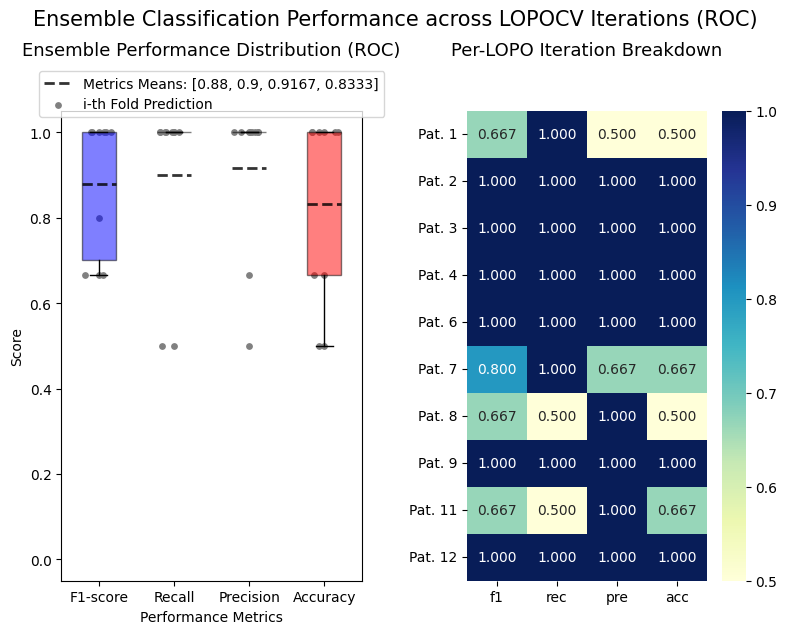

In [19]:
show_dotbox_heat(roc_ens_metrics_dicts,
                 dots = True,
                 title_1 = 'Ensemble Performance Distribution (ROC)',
                 title_2 = 'Per-LOPO Iteration Breakdown',
                 sup_title = 'Ensemble Classification Performance across LOPOCV Iterations (ROC)',
                 file_name = f'ensemble_perf_distr_{exp_plot_name}_ROC',
                 save_dir = save_direct_plot_ROC,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = sub_figsize,
                 legend_pos = 1.1, fold_or_seed = 'Fold')

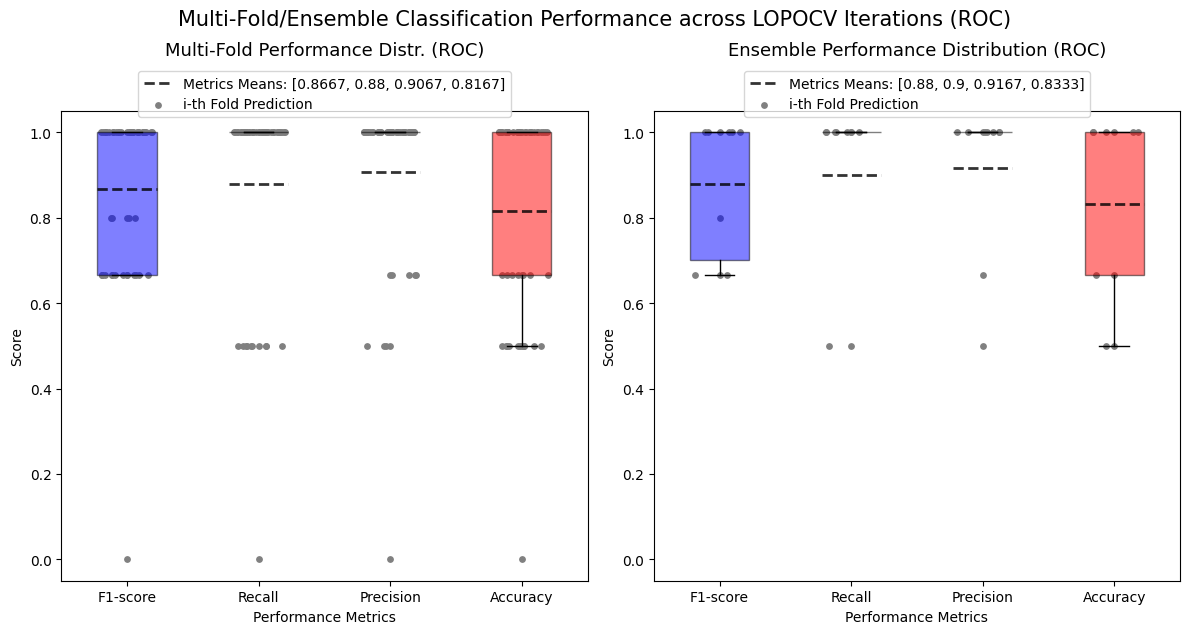

In [20]:
show_dotbox_dotbox(roc_ens_metrics_dicts, all_ROC_metrics_across_LOPO,
                 dots = True,
                 title_1 = 'Multi-Fold Performance Distr. (ROC)',
                 title_2 = 'Ensemble Performance Distribution (ROC)',

                 sup_title = 'Multi-Fold/Ensemble Classification Performance across LOPOCV Iterations (ROC)',
                 file_name = f'multi_ensemble_perf_distr_{exp_plot_name}_ROC',
                 save_dir = save_direct_plot_ROC,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = (6,5),
                 legend_pos = 1.1, fold_or_seed = 'Fold')

# Ensemble Resampling Prediction (RES)

In [21]:

save_direct_plot_RES = f'{thesis_images_dir}/{exp_plot_name}_ens/RES/'
os.makedirs(save_direct_plot_RES, exist_ok=True)


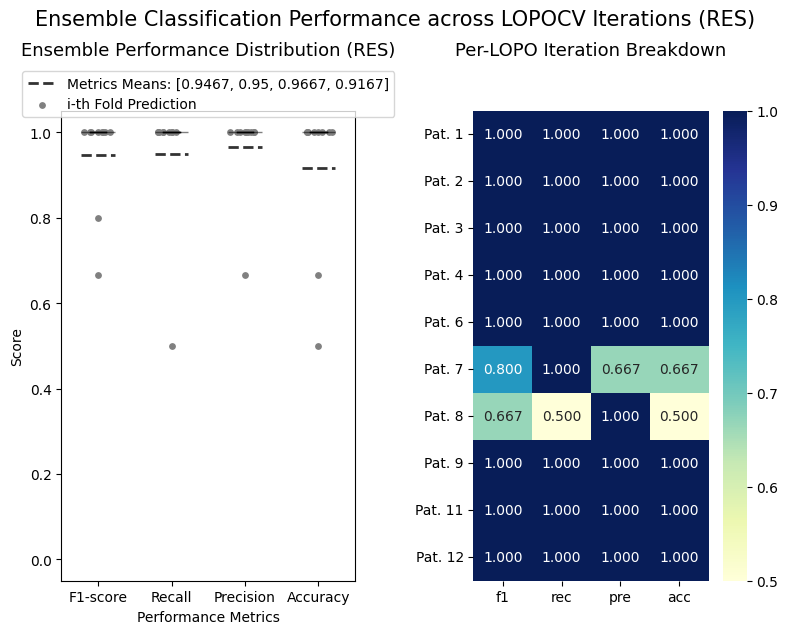

In [22]:
show_dotbox_heat(res_ens_metrics_dicts,
                 dots = True,
                 title_1 = 'Ensemble Performance Distribution (RES)',
                 title_2 = 'Per-LOPO Iteration Breakdown',
                 sup_title = 'Ensemble Classification Performance across LOPOCV Iterations (RES)',
                 file_name = f'ensemble_perf_distr_{exp_plot_name}_RES',
                 save_dir = save_direct_plot_RES,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = sub_figsize,
                 legend_pos = 1.1, fold_or_seed = 'Fold')

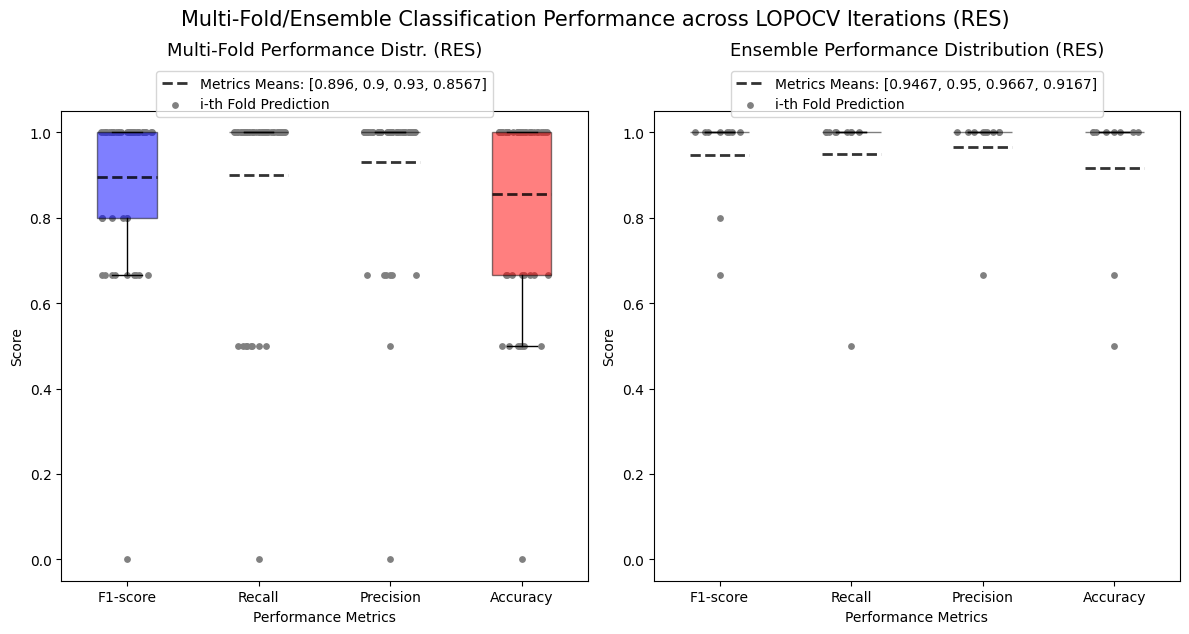

In [23]:
show_dotbox_dotbox(res_ens_metrics_dicts, all_RES_metrics_across_LOPO,
                 dots = True,
                 title_1 = 'Multi-Fold Performance Distr. (RES)',
                 title_2 = 'Ensemble Performance Distribution (RES)',
                 fold_or_seed = 'Fold',
                 sup_title = 'Multi-Fold/Ensemble Classification Performance across LOPOCV Iterations (RES)',
                 file_name = f'multi_ensemble_perf_distr_{exp_plot_name}_RES',
                 save_dir = save_direct_plot_RES,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = (6,5),
                 legend_pos = 1.1)

In [24]:
tables_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/DIR/'
os.makedirs(tables_dir, exist_ok=True)

all_lopo_mean_std_dict = compute_mean_std_metrics(all_dir_metrics_across_LOPO, 4)
across_lopo_mean_std_dict = compute_mean_std_metrics(all_dir_ens_metrics, 4)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_dict , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_dict , f)

all_lopo_mean_std_df = compute_mean_std_metrics(all_dir_metrics_across_LOPO, return_df=True)
across_lopo_mean_std_df = compute_mean_std_metrics(all_dir_ens_metrics, return_df=True)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_df.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_df , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_df.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_df , f)

print(all_lopo_mean_std_dict)
print(across_lopo_mean_std_dict)
print('')


tables_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/ROC/'
os.makedirs(tables_dir, exist_ok=True)

all_lopo_mean_std_dict_ROC = compute_mean_std_metrics(all_ROC_metrics_across_LOPO, 4)
across_lopo_mean_std_dict_ROC = compute_mean_std_metrics(roc_ens_metrics_dicts, 4)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_dict_ROC.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_dict_ROC , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_dict_ROC.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_dict_ROC , f)

all_lopo_mean_std_df_ROC = compute_mean_std_metrics(all_ROC_metrics_across_LOPO, return_df=True)
across_lopo_mean_std_df_ROC = compute_mean_std_metrics(roc_ens_metrics_dicts, return_df=True)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_df_ROC.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_df_ROC , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_df_ROC.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_df_ROC , f)

print(all_lopo_mean_std_dict)
print(across_lopo_mean_std_dict)
print('')

tables_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/RES/'
os.makedirs(tables_dir, exist_ok=True)

all_lopo_mean_std_dict_RES = compute_mean_std_metrics(all_RES_metrics_across_LOPO, 4)
across_lopo_mean_std_dict_RES = compute_mean_std_metrics(res_ens_metrics_dicts, 4)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_dict_RES.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_dict_RES , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_dict_RES.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_dict_RES , f)

all_lopo_mean_std_df_RES = compute_mean_std_metrics(all_RES_metrics_across_LOPO, return_df=True)
across_lopo_mean_std_df_RES = compute_mean_std_metrics(res_ens_metrics_dicts, return_df=True)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_df_RES.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_df_RES , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_df_RES.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_df_RES , f)


print(all_lopo_mean_std_dict)
print(across_lopo_mean_std_dict)

{'f1': [np.float64(0.8813), np.float64(0.1375)], 'rec': [np.float64(0.96), np.float64(0.137)], 'pre': [np.float64(0.8533), np.float64(0.1953)], 'acc': [np.float64(0.8167), np.float64(0.2082)]}
{'f1': [np.float64(0.84), np.float64(0.1481)], 'rec': [np.float64(0.95), np.float64(0.1581)], 'pre': [np.float64(0.8), np.float64(0.2194)], 'acc': [np.float64(0.75), np.float64(0.2257)]}

{'f1': [np.float64(0.8813), np.float64(0.1375)], 'rec': [np.float64(0.96), np.float64(0.137)], 'pre': [np.float64(0.8533), np.float64(0.1953)], 'acc': [np.float64(0.8167), np.float64(0.2082)]}
{'f1': [np.float64(0.84), np.float64(0.1481)], 'rec': [np.float64(0.95), np.float64(0.1581)], 'pre': [np.float64(0.8), np.float64(0.2194)], 'acc': [np.float64(0.75), np.float64(0.2257)]}

{'f1': [np.float64(0.8813), np.float64(0.1375)], 'rec': [np.float64(0.96), np.float64(0.137)], 'pre': [np.float64(0.8533), np.float64(0.1953)], 'acc': [np.float64(0.8167), np.float64(0.2082)]}
{'f1': [np.float64(0.84), np.float64(0.1481)]

# All Boxplots Ensemble

In [25]:
thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)





0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
[2, 4, 6, 9, 11, 14, 16, 18, 21, 23]
[[np.float64(0.9759448575973511), np.float64(0.9831866490840911), np.float64(0.9988098653157553), np.float64(0.9999723728497824), np.float64(0.9996739053726195)], [np.float64(0.7620519872506459), np.float64(0.7510318426291148), np.float64(0.7319570773839951), np.float64(0.38975435892740884), np.float64(0.3606208314498265)], [np.float64(0.7414811380704245), np.float64(0.5062263057598223), np.float64(0.99987633784612), np.float64(0.8032055040200551), np.float64(0.702883536418279)], [np.float64(0.8449794995784758), np.float64(0.5220964548985164), np.float64(0.9998694105943043), np.float64(0.9966446216901143), np.float64(0.7910216061274211)], [np.float64(0.9748627706368765), np.float64(0.9999979440371195), np.float64(0.9999988730748494), np.float64(0.9190527542432149), np.float64(0.9710444402694702)], [np.float64(0.8378296260039011), np.float64(0.34277367

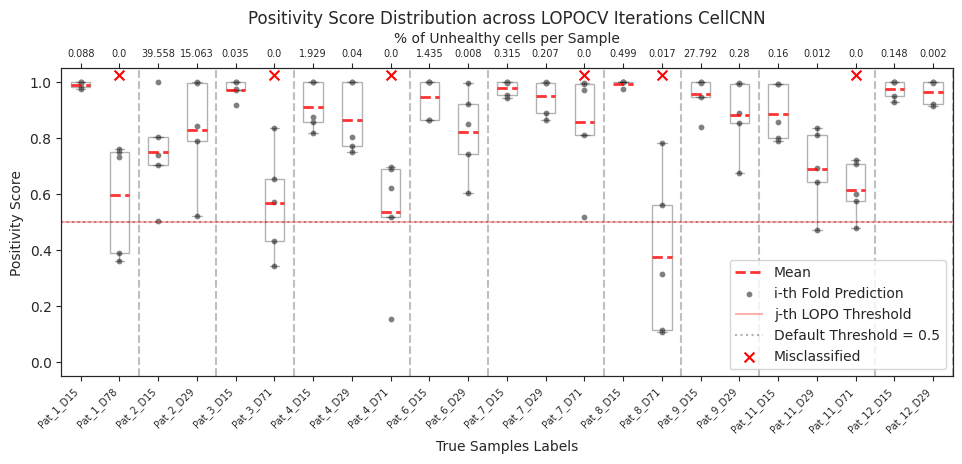

[2, 4, 6, 9, 11, 14, 16, 18, 21, 23]
[[np.float64(0.9759448575973511), np.float64(0.9831866490840911), np.float64(0.9988098653157553), np.float64(0.9999723728497824), np.float64(0.9996739053726195)], [np.float64(0.7620519872506459), np.float64(0.7510318426291148), np.float64(0.7319570773839951), np.float64(0.38975435892740884), np.float64(0.3606208314498265)], [np.float64(0.7414811380704245), np.float64(0.5062263057598223), np.float64(0.99987633784612), np.float64(0.8032055040200551), np.float64(0.702883536418279)], [np.float64(0.8449794995784758), np.float64(0.5220964548985164), np.float64(0.9998694105943043), np.float64(0.9966446216901143), np.float64(0.7910216061274211)], [np.float64(0.9748627706368765), np.float64(0.9999979440371195), np.float64(0.9999988730748494), np.float64(0.9190527542432149), np.float64(0.9710444402694702)], [np.float64(0.8378296260039011), np.float64(0.34277367989222207), np.float64(0.57413248082002), np.float64(0.6545953365166983), np.float64(0.4325055333971

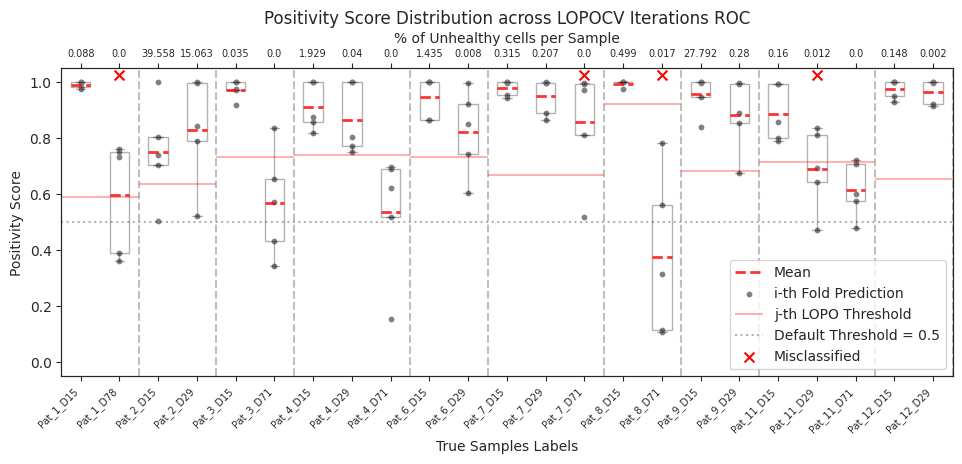

[2, 4, 6, 9, 11, 14, 16, 18, 21, 23]
[[np.float64(0.9759448575973511), np.float64(0.9831866490840911), np.float64(0.9988098653157553), np.float64(0.9999723728497824), np.float64(0.9996739053726195)], [np.float64(0.7620519872506459), np.float64(0.7510318426291148), np.float64(0.7319570773839951), np.float64(0.38975435892740884), np.float64(0.3606208314498265)], [np.float64(0.7414811380704245), np.float64(0.5062263057598223), np.float64(0.99987633784612), np.float64(0.8032055040200551), np.float64(0.702883536418279)], [np.float64(0.8449794995784758), np.float64(0.5220964548985164), np.float64(0.9998694105943043), np.float64(0.9966446216901143), np.float64(0.7910216061274211)], [np.float64(0.9748627706368765), np.float64(0.9999979440371195), np.float64(0.9999988730748494), np.float64(0.9190527542432149), np.float64(0.9710444402694702)], [np.float64(0.8378296260039011), np.float64(0.34277367989222207), np.float64(0.57413248082002), np.float64(0.6545953365166983), np.float64(0.4325055333971

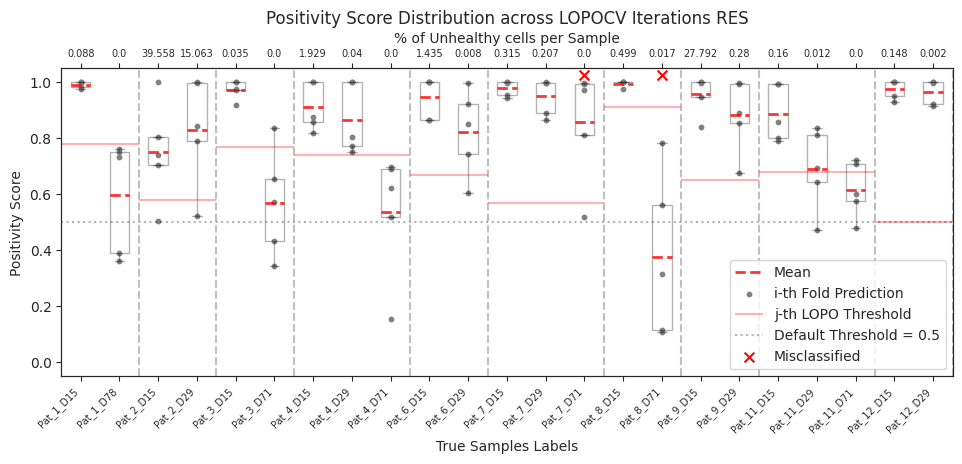

In [26]:

ens_per_LOPO_blast_perc = []
ens_per_LOPO_boxplot_data = []


for LOPO_idx, _ in enumerate(range(LOPO_folds)):
    save_ensemble_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPO_idx}/ensemble/results/' #inner_fold_{inner_fold}/robust/{thr_type}'

    test_pat = LOPOCV_patients_folds[LOPO_idx][1]

    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    per_donor_original_test_datasets, per_donor_original_test_y = retrieve_labels(test_datasets_extracted, remove = False)


    patient_blast_perc = retrieve_blast_perc(per_donor_original_test_datasets)
    ens_per_LOPO_blast_perc.append(patient_blast_perc)

    num_samples = len(flatten(per_donor_original_test_y))

    # classification using ROC
    _, cv_box_mean_across_folds = elaborate_ens_data_for_box_violin(save_ensemble_dir, ens_roc_thr_per_fold, num_samples)
    ens_per_LOPO_boxplot_data.append(cv_box_mean_across_folds)


#===========#
# Show Ensemble Boxplot and Violin plot
#===========#
pat_sample_ids = retireve_sorted_pat_sample_ids(samples_info_dict)
default_thr_list = [0.5 for i in range(len(ens_roc_thr_per_fold))]

thr_list_coll = [default_thr_list, ens_roc_thr_per_fold, ens_res_thr_per_fold]

#violin_data_coll = [ens_roc_per_LOPO_violin_data, ens_rob_per_LOPO_violin_data]
type_thr = ['CellCNN', 'ROC', 'RES']
for z, (thr_list, type_pred) in enumerate(zip(thr_list_coll, type_thr)):
 # if z == 1:
    save_direct_plot = f'{thesis_images_dir}/{exp_plot_name}_ens/{type_pred}/'
    os.makedirs(save_direct_plot, exist_ok=True)


    num_samples_cum = comulative_num_samples_sum(ens_per_LOPO_boxplot_data)
    ens_per_LOPO_boxplot_data_flat = flatten(ens_per_LOPO_boxplot_data)
    ens_per_LOPO_blast_perc_flat = flatten(ens_per_LOPO_blast_perc)

    show_all_LOPO_boxplots(ens_per_LOPO_boxplot_data_flat, ens_per_LOPO_blast_perc_flat, thr_list,
                           num_samples_cum,  save_dir = save_direct_plot,
                           file_name = f'samples_boxplots_per_lopocv_ens_{type_pred}.pdf',
                           title = f'Positivity Score Distribution across LOPOCV Iterations {type_pred}',
                           fold_or_seed = 'Fold',
                           y_labels = pat_sample_ids)

import pickle
pos_score_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/'
os.makedirs(pos_score_dir, exist_ok=True)

with open(os.path.join(pos_score_dir, 'thr_list_coll.pkl'), 'wb') as f:
        pickle.dump(thr_list_coll , f)
with open(os.path.join(pos_score_dir, 'boxplot_data_coll.pkl'), 'wb') as f:
        pickle.dump(ens_per_LOPO_boxplot_data , f)
